In [2]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import classification_report
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets        import make_classification
from sklearn.preprocessing   import RobustScaler

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import StackingClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.linear_model   import SGDClassifier
from sklearn.svm            import SVC
from sklearn.svm            import LinearSVC
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier
from sklearn.ensemble       import HistGradientBoostingClassifier


# hyperopt 용
from hyperopt               import hp

# 사용자 Functions import
import HyperParams          as HP 
import utils.data_sampling  as ds 

import importlib

from utils import hyperopt_search
importlib.reload(hyperopt_search)


from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

from utils.hyperopt_search import hyperopt_search, train_and_evaluate
from utils.results_report  import load_results_to_df

In [ ]:
# results_for_graph = {
#     # ---------- Oversampling ----------
#     "CatBoost_Over": {"AUC": 1.0000, "정밀도": 0.9991, "재현율": 1.0000, "F1": 0.9995},
#     "GB_Over": {"AUC": 0.9985, "정밀도": 0.9863, "재현율": 0.9713, "F1": 0.9787},
#     "DT_Over": {"AUC": 0.9982, "정밀도": 0.9975, "재현율": 0.9990, "F1": 0.9983},
#     "MLP_Over": {"AUC": 1.0000, "정밀도": 0.9994, "재현율": 1.0000, "F1": 0.9997},

#     # ---------- Undersampling ----------
#     "CatBoost_Under": {"AUC": 0.9736, "정밀도": 0.9663, "재현율": 0.8776, "F1": 0.9198},
#     "GB_Under": {"AUC": 0.9767, "정밀도": 0.9565, "재현율": 0.8980, "F1": 0.9263},
#     "DT_Under": {"AUC": 0.8882, "정밀도": 0.9130, "재현율": 0.8571, "F1": 0.8842},
#     "MLP_Under": {"AUC": 0.9774, "정밀도": 0.9574, "재현율": 0.9184, "F1": 0.9375}
# }
df_results = load_results_to_df('../results', sort_by='F1', ascending=False)

In [5]:
df_results

,model_name,file_name,AUC,정확도,정밀도,재현율,F1,F2,실행시간
0,ovesample_capped_mlp_ejm,ovesample_capped_mlp_ejm_20251127.txt,1.0000,0.9997,0.9994,1.0000,0.9997,NaN,NaN
1,ovesample_capped_catboost_ejm,ovesample_capped_catboost_ejm_20251127.txt,1.0000,0.9995,0.9991,1.0000,0.9995,NaN,NaN
2,ovesample_mlp_ejm,ovesample_mlp_ejm_20251127.txt,1.0000,0.9994,0.9991,0.9996,0.9994,NaN,NaN
3,ovesample_catboost_ejm,ovesample_catboost_ejm_20251127.txt,1.0000,0.9992,0.9985,1.0000,0.9992,NaN,NaN
4,ovesample_capped_dt_ejm,ovesample_capped_dt_ejm_20251127.txt,0.9982,0.9983,0.9975,0.9990,0.9983,NaN,NaN
...,...,...,...,...,...,...,...,...,...
172,XGB_ho_rscaled_under,XGB_ho_rscaled_under_20251129.txt,0.9729,0.8389,0.0099,0.9388,0.0197,NaN,NaN
173,XGB_ho_rscaled_smote,XGB_ho_rscaled_smote_20251129.txt,0.9546,0.8137,0.0085,0.9286,0.0169,NaN,NaN
174,XGB_ho_rscaled_combined,XGB_ho_rscaled_combined_20251129.txt,0.9546,0.8137,0.0085,0.9286,0.0169,NaN,NaN
175,xgb_ho_tr_over_best,xgb_ho_tr_over_best_20251129.txt,0.9697,0.8009,0.0081,0.9388,0.0160,NaN,NaN


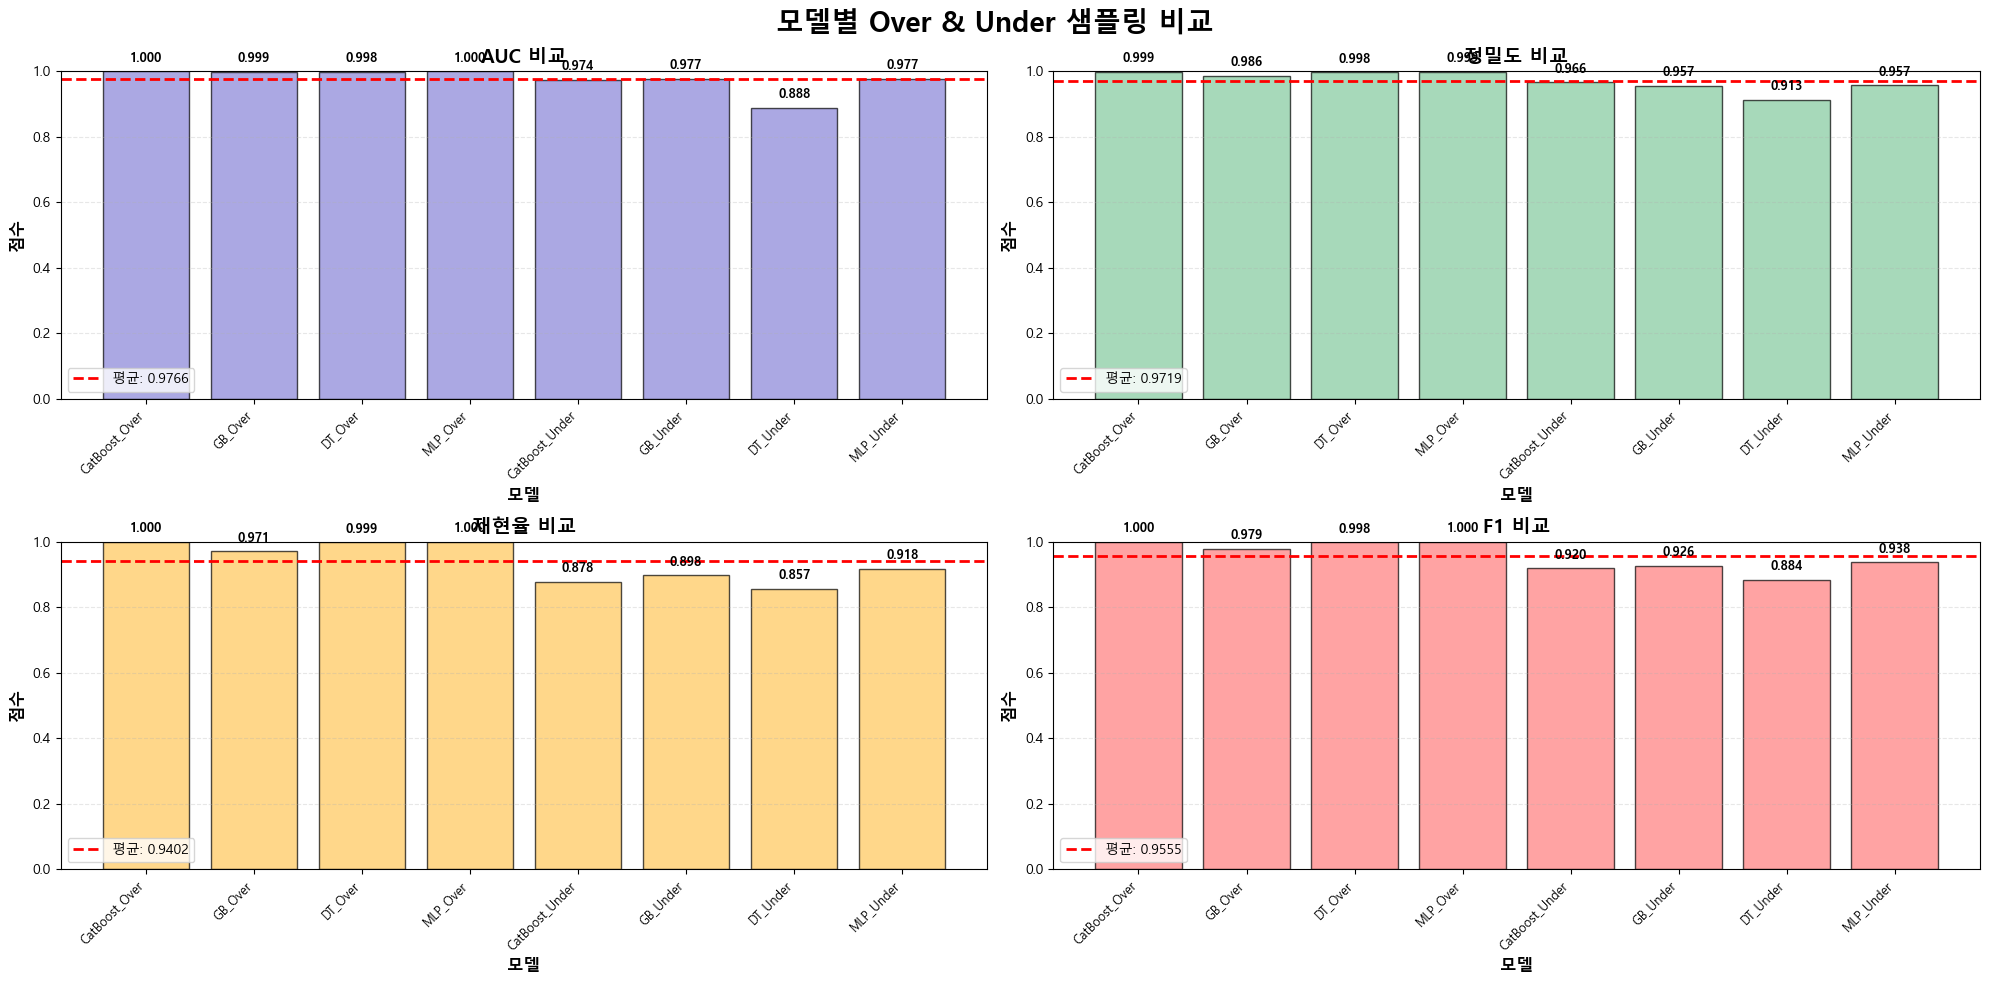


=== 지표별 통계 요약 ===

[AUC]
  최고: 1.0000 (CatBoost_Over)
  최저: 0.8882 (DT_Under)
  평균: 0.9766
  표준편차: 0.0375

[정밀도]
  최고: 0.9994 (MLP_Over)
  최저: 0.9130 (DT_Under)
  평균: 0.9719
  표준편차: 0.0300

[재현율]
  최고: 1.0000 (CatBoost_Over)
  최저: 0.8571 (DT_Under)
  평균: 0.9402
  표준편차: 0.0594

[F1]
  최고: 0.9997 (MLP_Over)
  최저: 0.8842 (DT_Under)
  평균: 0.9555
  표준편차: 0.0444


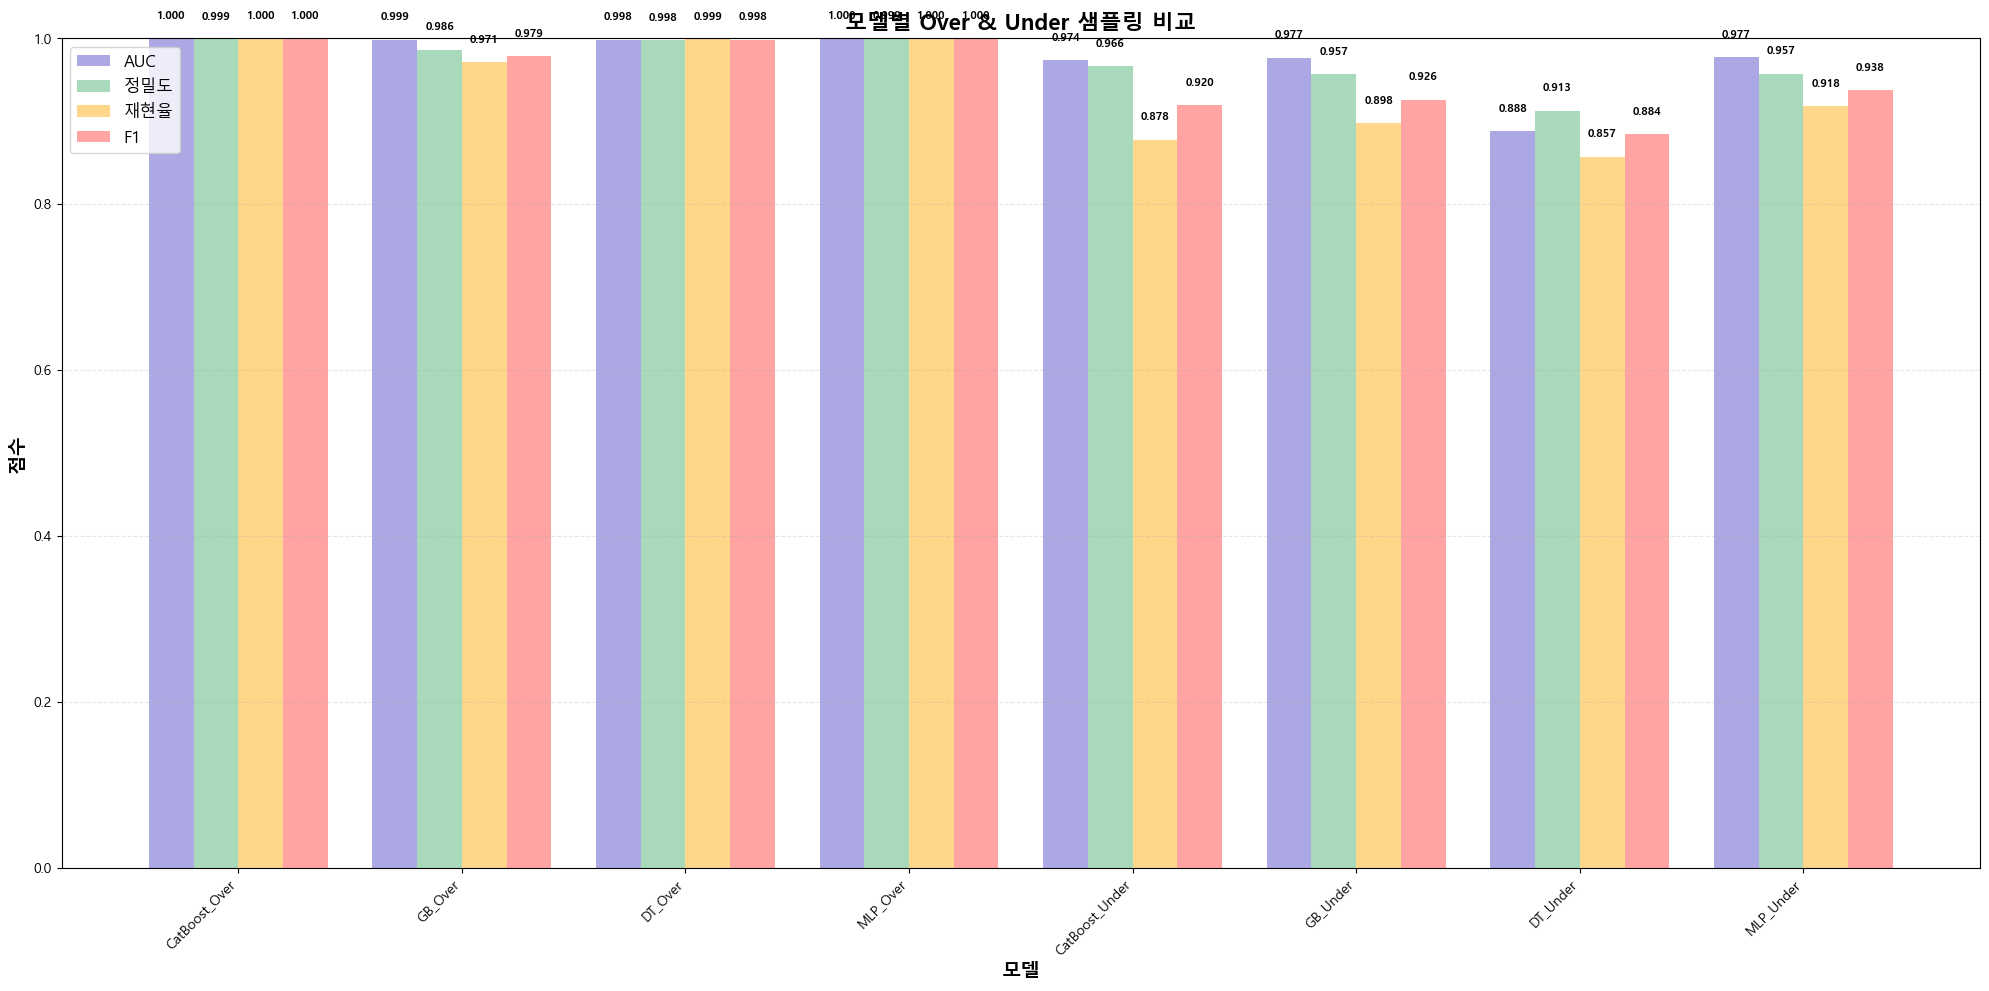


=== F1 Score 기준 상위 5개 모델 ===
                  AUC     정밀도     재현율      F1
MLP_Over       1.0000  0.9994  1.0000  0.9997
CatBoost_Over  1.0000  0.9991  1.0000  0.9995
DT_Over        0.9982  0.9975  0.9990  0.9983
GB_Over        0.9985  0.9863  0.9713  0.9787
MLP_Under      0.9774  0.9574  0.9184  0.9375

=== AUC 기준 상위 5개 모델 ===
                  AUC     정밀도     재현율      F1
CatBoost_Over  1.0000  0.9991  1.0000  0.9995
MLP_Over       1.0000  0.9994  1.0000  0.9997
GB_Over        0.9985  0.9863  0.9713  0.9787
DT_Over        0.9982  0.9975  0.9990  0.9983
MLP_Under      0.9774  0.9574  0.9184  0.9375

그래프가 저장되었습니다: ../images/모델별_Over_&_Under_샘플링_비교_2025_1208.png


In [ ]:
# 시각화
mo.model_metrics_graph(results_for_graph, '모델별 Over & Under 샘플링 비교')

In [ ]:
# 시각화
mo.model_metrics_graph(results_for_graph, '모델별 Over & Under 샘플링 비교')